In [1]:
import os
import pandas as pd
import scanpy as sc
from scipy.io import mmread

base_dir = r"C:/Users/ankit/Documents/scFM/train_data/GSE174748"


In [ ]:



sample_info = {
    "GSM5325534_healthy1": "healthy",
    "GSM5325535_healthy2": "healthy",
    "GSM5325536_nafld1": "nafld",
    "GSM5325537_nafld2": "nafld",
}

adatas = []

for sample_name, condition in sample_info.items():
    sample_dir = os.path.join(base_dir, sample_name)

    barcodes_path = os.path.join(sample_dir, "barcodes.tsv.gz")
    features_path = os.path.join(sample_dir, "features.tsv.gz")
    matrix_path = os.path.join(sample_dir, "matrix.mtx.gz")

    # Read matrix and transpose to cells x genes
    X = mmread(matrix_path).tocsr().T

    # Read barcodes and features
    barcodes = pd.read_csv(barcodes_path, header=None, sep="\t")
    barcodes.columns = ["barcode"]

    features = pd.read_csv(features_path, header=None, sep="\t")
    features.columns = ["gene_id", "gene_symbol", "feature_type"]

    # Build AnnData
    adata = sc.AnnData(X=X)

    # Cell metadata
    adata.obs_names = [f"{bc}_{sample_name}" for bc in barcodes["barcode"].astype(str)]
    adata.obs["barcode"] = barcodes["barcode"].astype(str).values
    adata.obs["sample"] = sample_name
    adata.obs["condition"] = condition
    adata.obs["gsm_id"] = sample_name.split("_")[0]

    # Gene metadata
    adata.var_names = features["gene_symbol"].astype(str).values
    adata.var["gene_id"] = features["gene_id"].astype(str).values
    adata.var["gene_symbol"] = features["gene_symbol"].astype(str).values
    adata.var["feature_type"] = features["feature_type"].astype(str).values
    adata.var_names_make_unique()

    adatas.append(adata)

# Merge all samples
adata_merged = sc.concat(
    adatas,
    join="outer",
    label="batch",
    keys=[a.obs["sample"].iloc[0] for a in adatas],
    index_unique=None
)

print(adata_merged)
print(adata_merged.obs["condition"].value_counts())
print(adata_merged.obs["sample"].value_counts())

# Optional: save
adata_merged.write(os.path.join(base_dir, "GSE174748_from_raw.h5ad"))

AnnData object with n_obs × n_vars = 27179520 × 33538
    obs: 'barcode', 'sample', 'condition', 'gsm_id', 'batch'
condition
healthy    13589760
nafld      13589760
Name: count, dtype: int64
sample
GSM5325534_healthy1    6794880
GSM5325535_healthy2    6794880
GSM5325536_nafld1      6794880
GSM5325537_nafld2      6794880
Name: count, dtype: int64


In [2]:
# Read in the processed data
adata = sc.read_h5ad("GSE174748_from_raw.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 4524728 × 33538
    obs: 'barcode', 'sample', 'condition', 'gsm_id', 'batch', 'assay_type'


In [9]:
import numpy as np
from scipy import sparse

X = adata_merged.X

if sparse.issparse(X):
    total_counts = np.asarray(X.sum(axis=1)).ravel()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()
else:
    total_counts = X.sum(axis=1)
    genes_per_cell = np.sum(X > 0, axis=1)

# Remove empty barcodes
adata_merged = adata_merged[(total_counts > 0) & (genes_per_cell > 0)].copy()

print(adata_merged)

AnnData object with n_obs × n_vars = 4524728 × 33538
    obs: 'barcode', 'sample', 'condition', 'gsm_id', 'batch'


In [22]:
print(adata_merged)


AnnData object with n_obs × n_vars = 4524728 × 33538
    obs: 'barcode', 'sample', 'condition', 'gsm_id', 'batch', 'assay_type'


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

X = adata_merged.X

if sparse.issparse(X):
    X = X.tocsc()
    genes_per_cell = np.asarray((X > 0).sum(axis=1)).ravel()
    cells_per_gene = np.asarray((X > 0).sum(axis=0)).ravel()
else:
    genes_per_cell = np.sum(X > 0, axis=1)
    cells_per_gene = np.sum(X > 0, axis=0)

# Determine the minimum and maximum number of genes per cell
min_genes_per_cell = np.min(genes_per_cell)
print(f"Minimum number of genes per cell: {min_genes_per_cell}")
# Determine how many cells have at least the minimum number of genes
num_cells_with_min_genes = np.sum(genes_per_cell == min_genes_per_cell)
print(f"Number of cells with {min_genes_per_cell} genes: {num_cells_with_min_genes}")

Minimum number of genes per cell: 1
Number of cells with 1 genes: 3209768


In [23]:
adata_merged.write(os.path.join(base_dir, "GSE174748_from_raw.h5ad"))

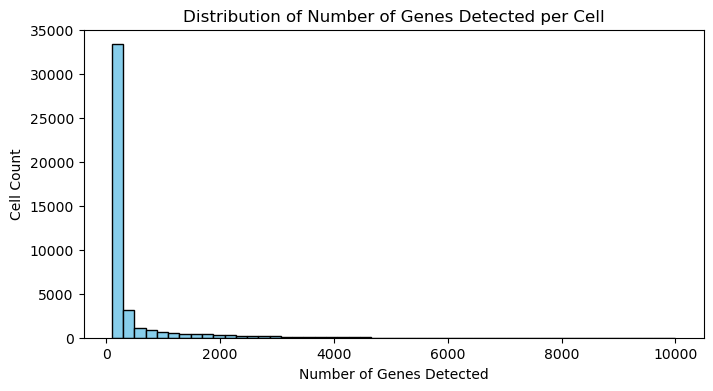

In [15]:
# Plot histogram of number of genes detected per cell in range 0 - 1000
import matplotlib.pyplot as plt
import scipy.sparse as sp

if "n_genes" not in adata.obs.columns:
	if "nFeature_RNA" in adata.obs.columns:
		adata.obs["n_genes"] = adata.obs["nFeature_RNA"]
	else:
		if sp.issparse(adata.X):
			adata.obs["n_genes"] = (adata.X > 0).sum(axis=1).A1
		else:
			adata.obs["n_genes"] = (adata.X > 0).sum(axis=1)

plt.figure(figsize=(8, 4))
plt.hist(adata.obs["n_genes"], bins=50, range=(100, 10000), color="skyblue", edgecolor="black")
plt.title("Distribution of Number of Genes Detected per Cell")
plt.xlabel("Number of Genes Detected")
plt.ylabel("Cell Count")
plt.show()


In [16]:
# Plot histogram of cell counts per gene in range 0 - 100
if sp.issparse(adata.layers['counts']):
	adata.var["n_cells"] = (adata.layers['counts'] > 0).sum(axis=0).A1
else:
	adata.var["n_cells"] = (adata.layers['counts'] > 0).sum(axis=0)
plt.figure(figsize=(8, 5))  
plt.hist(adata.var["n_cells"], bins=50, range=(0, 10))
plt.xlabel("Number of Cells Expressing Gene")
plt.ylabel("Frequency")
plt.title("Distribution of Cell Counts per Gene")
plt.show()


KeyError: 'counts'